Yearbook-level summary:
                     yearbook_name  yearbook_state  total_students  \
0          Lowell 1940 Senior Male      California             188   
1        Lowell 1940 Senior Female      California             217   
2          Lion 1941 Senior Junior      California             121   
3     Lion 1941 Sophomore Freshmen      California             177   
4            Afterglow 1940 Senior      California              86   
5          Washington 1939 Juniors         Indiana             262   
6               Globe 1939 Seniors         Arizona             164   
7       Ayantee 1940 Senior Junior  North Carolina             178   
8            Cleveland 1940 Senior  North Carolina              21   
9                  Crossroads 1941  North Carolina             122   
10  Phoenix Union High School 1941         Arizona             147   
11        Fremont High School 1939      California             270   
12     Valparaiso High School 1941         Indiana             520

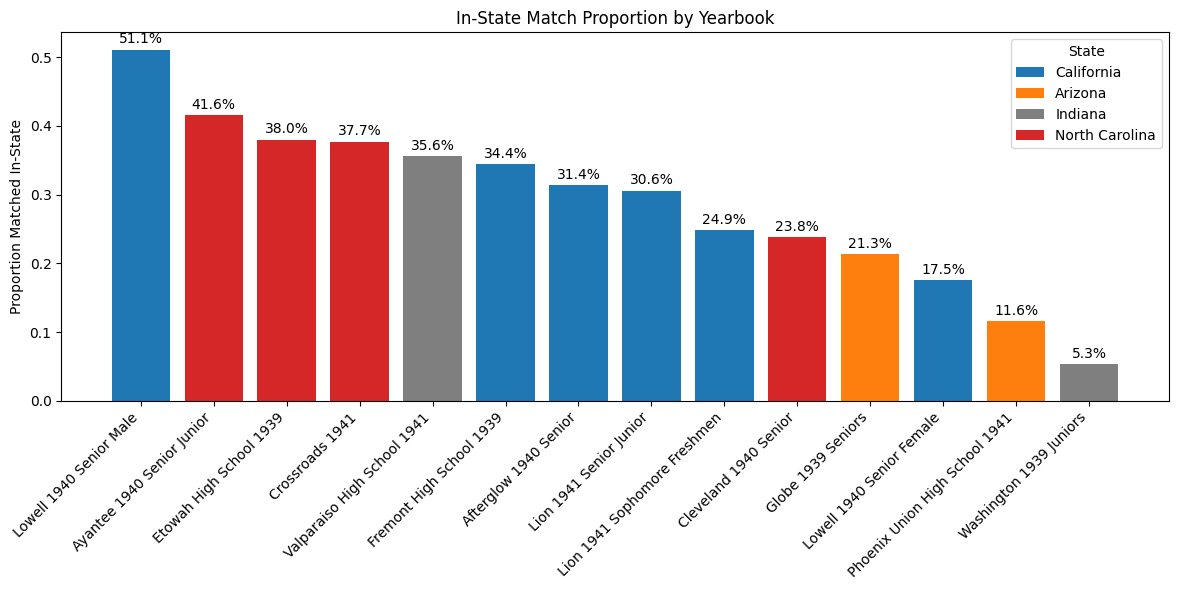


State-level summary:
   yearbook_state  total_students  unique_matches_in_state  match_rate
3  North Carolina             429                      166    0.386946
1      California            1059                      335    0.316336
2         Indiana             782                      199    0.254476
0         Arizona             311                       52    0.167203


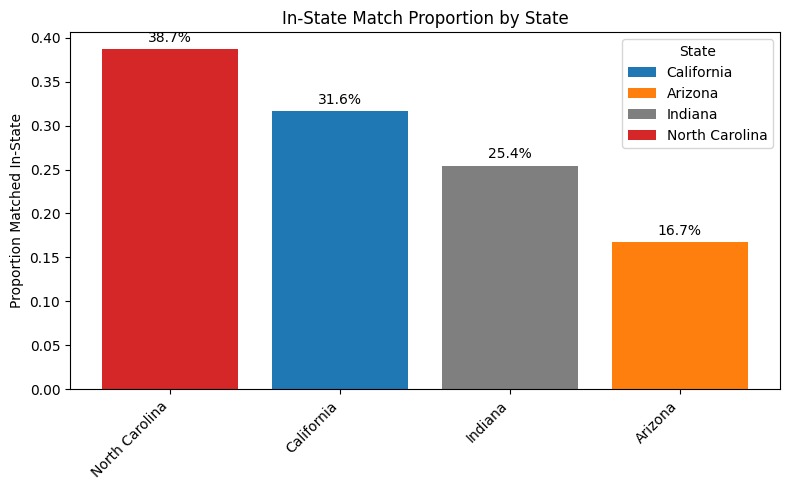

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

def analyze_yearbook(csv_path, yearbook_name, yearbook_year, yearbook_state, total_students):
    df = pd.read_csv(csv_path)

    df["yearbook_name"] = yearbook_name
    df["yearbook_year"] = yearbook_year
    df["yearbook_state"] = yearbook_state

    filtered = df[
        (
            (df["bpl_string"] == df["yearbook_state"]) |
            (df["socstate_string"] == df["yearbook_state"])
        )
        & df["match_method"].notna()
    ].copy()

    unique_matches = filtered["yearbook_person"].nunique()
    match_rate = unique_matches / total_students if total_students > 0 else 0

    summary = {
        "yearbook_name": yearbook_name,
        "yearbook_year": yearbook_year,
        "yearbook_state": yearbook_state,
        "total_students": total_students,
        "unique_matches_in_state": unique_matches,
        "match_rate": match_rate
    }

    return df, filtered, summary


# -----------------------------
# MANUALLY ENTER YOUR YEARBOOKS
# -----------------------------
base = "/Users/nickichen/Desktop/urap data/yearbook_results"

yearbooks = [
    {
        "csv_path": f"{base}/Lowell 1940 male_1940_matches.csv",
        "yearbook_name": "Lowell 1940 Senior Male",
        "yearbook_year": 1940,
        "yearbook_state": "California",
        "total_students": 188
    },
    {
        "csv_path": f"{base}/Lowell 1940 female_1940_matches.csv",
        "yearbook_name": "Lowell 1940 Senior Female",
        "yearbook_year": 1940,
        "yearbook_state": "California",
        "total_students": 217
    },
    {
        "csv_path": f"{base}/Lion 1941 senior_1940_matches.csv",
        "yearbook_name": "Lion 1941 Senior Junior",
        "yearbook_year": 1941,
        "yearbook_state": "California",
        "total_students": 121
    },
    {
        "csv_path": f"{base}/Lion 1941 soph fresh_1940_matches.csv",
        "yearbook_name": "Lion 1941 Sophomore Freshmen",
        "yearbook_year": 1941,
        "yearbook_state": "California",
        "total_students": 97 + 80
    },
    {
        "csv_path": f"{base}/Afterglow 1940_1940_matches.csv",
        "yearbook_name": "Afterglow 1940 Senior",
        "yearbook_year": 1940,
        "yearbook_state": "California",
        "total_students": 86
    },
    {
        "csv_path": f"{base}/Washington High School (used juniors only)_1939_matches.csv",
        "yearbook_name": "Washington 1939 Juniors",
        "yearbook_year": 1939,
        "yearbook_state": "Indiana",
        "total_students": 262
    },
    {
        "csv_path": f"{base}/Globe High School (used seniors only)_1939_matches.csv",
        "yearbook_name": "Globe 1939 Seniors",
        "yearbook_year": 1939,
        "yearbook_state": "Arizona",
        "total_students": 90 + 74
    },
    {
        "csv_path": f"{base}/Ayantee_1940_matches.csv",
        "yearbook_name": "Ayantee 1940 Senior Junior",
        "yearbook_year": 1940,
        "yearbook_state": "North Carolina",
        "total_students": 178
    },
    {
        "csv_path": f"{base}/Cleveland_1940_matches.csv",
        "yearbook_name": "Cleveland 1940 Senior",
        "yearbook_year": 1940,
        "yearbook_state": "North Carolina",
        "total_students": 21
    },
    {
        "csv_path": f"{base}/Crossroads_1941_matches.csv",
        "yearbook_name": "Crossroads 1941",
        "yearbook_year": 1941,
        "yearbook_state": "North Carolina",
        "total_students": 122
    }
    ,
    {
        "csv_path": f"{base}/Phoenix Union High School_1941_matches.csv",
        "yearbook_name": "Phoenix Union High School 1941",
        "yearbook_year": 1941,
        "yearbook_state": "Arizona",
        "total_students": 147
    },
    {
        "csv_path": f"{base}/Fremont High School (Seniors only)_1939_matches.csv",
        "yearbook_name": "Fremont High School 1939",
        "yearbook_year": 1939,
        "yearbook_state": "California",
        "total_students": 270
    },
    {
        "csv_path": f"{base}/Valparaiso Union High School_1941_matches.csv",
        "yearbook_name": "Valparaiso High School 1941",
        "yearbook_year": 1941,
        "yearbook_state": "Indiana",
        "total_students": 92+71+68+64+82+67+76 #520
    }, 
    {
        "csv_path": f"{base}/Etowah High School_1939_matches.csv",
        "yearbook_name": "Etowah High School 1939",
        "yearbook_year": 1939,
        "yearbook_state": "North Carolina",
        "total_students": 108
    }

]

# -----------------------------
# COLOR MAP BY STATE
# -----------------------------
state_colors = {
    "California": "tab:blue",
    "Arizona": "tab:orange",
    "Indiana": "tab:grey",
    "North Carolina": "tab:red"
}

all_full_dfs = []
all_filtered_dfs = []
summary_rows = []

for yb in yearbooks:
    full_df, filtered_df, summary = analyze_yearbook(
        csv_path=yb["csv_path"],
        yearbook_name=yb["yearbook_name"],
        yearbook_year=yb["yearbook_year"],
        yearbook_state=yb["yearbook_state"],
        total_students=yb["total_students"]
    )

    all_full_dfs.append(full_df)
    all_filtered_dfs.append(filtered_df)
    summary_rows.append(summary)

summary_df = pd.DataFrame(summary_rows)

print("Yearbook-level summary:")
print(summary_df[[
    "yearbook_name",
    "yearbook_state",
    "total_students",
    "unique_matches_in_state",
    "match_rate"
]])

legend_handles = [
    Patch(facecolor=color, label=state)
    for state, color in state_colors.items()
]

# -----------------------------
# VISUAL 1: YEARBOOK-LEVEL MATCH RATE
# -----------------------------
yearbook_plot_df = summary_df.sort_values("match_rate", ascending=False).copy()
yearbook_labels = yearbook_plot_df["yearbook_name"]
yearbook_bar_colors = yearbook_plot_df["yearbook_state"].map(state_colors).fillna("gray")

plt.figure(figsize=(12, 6))
bars = plt.bar(yearbook_labels, yearbook_plot_df["match_rate"], color=yearbook_bar_colors)
plt.ylabel("Proportion Matched In-State")
plt.title("In-State Match Proportion by Yearbook")
plt.xticks(rotation=45, ha="right")

for bar, rate in zip(bars, yearbook_plot_df["match_rate"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.005,
        f"{rate:.1%}",
        ha="center",
        va="bottom"
    )

plt.legend(handles=legend_handles, title="State")
plt.tight_layout()
plt.show()

# -----------------------------
# STATE-LEVEL SUMMARY
# -----------------------------
state_summary = (
    summary_df.groupby("yearbook_state", as_index=False)
    .agg({
        "total_students": "sum",
        "unique_matches_in_state": "sum"
    })
)

state_summary["match_rate"] = (
    state_summary["unique_matches_in_state"] / state_summary["total_students"]
)

state_summary = state_summary.sort_values("match_rate", ascending=False)

print("\nState-level summary:")
print(state_summary)

# -----------------------------
# VISUAL 2: STATE-LEVEL MATCH RATE
# -----------------------------
state_bar_colors = state_summary["yearbook_state"].map(state_colors).fillna("gray")

plt.figure(figsize=(8, 5))
bars = plt.bar(state_summary["yearbook_state"], state_summary["match_rate"], color=state_bar_colors)
plt.ylabel("Proportion Matched In-State")
plt.title("In-State Match Proportion by State")
plt.xticks(rotation=45, ha="right")

for bar, rate in zip(bars, state_summary["match_rate"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.005,
        f"{rate:.1%}",
        ha="center",
        va="bottom"
    )

plt.legend(handles=legend_handles, title="State")
plt.tight_layout()
plt.show()